# Bootstrapping to estimate a probability

Group #1  
Harry Lazaridis, harrylaz@kth.se  
San Kaneskan, sanmo@kth.se

IX1501 Project 2

## Summary of the results and findings

This project estimated the probability that the mean of ten observations minus the unknown population mean lies between −4 and 3.5. We used the mean of the given sample, 76.7, to estimate the unknown mean. We then drew new samples of size ten from the observed values, with replacement.

With 1,000 bootstrap samples, 641 had a mean within the specified interval after subtracting 76.7. The estimated probability was therefore 0.641. We also repeated the estimation 20 times for each of three numbers of bootstrap samples. The estimates varied less when more bootstrap samples were used. Under a normal distribution assumption, the estimated probability was 0.6055. The two methods gave reasonably close results, although they use different assumptions.

## Description of the methodology

The observed values were 56, 101, 78, 67, 93, 87, 64, 72, 80 and 69. We treated them as one sample of ten independent observations. The task was to estimate the probability

$$p=P\left(-4<\bar X-\mu<3.5\right),$$

where $\bar X$ is the mean of a sample of size ten and $\mu$ is the unknown population mean. The sample mean of the observed data was $\bar x=76.7$, which we used as an estimate of $\mu$.

### Task 1 - Bootstrap method

For each bootstrap sample, we randomly selected ten values from the observed sample with replacement. This means that one value could be selected several times, while another might not be selected at all. We calculated the mean $\bar x^*$ of the new sample, subtracted the original mean $\bar x$, and checked whether the result was strictly between −4 and 3.5. The proportion of bootstrap samples that met this condition was our estimate of $p$.

```text
Calculate the mean of the original sample, x_bar
Set success_count = 0
Repeat N_B times:
    Draw 10 values from the original sample with replacement
    Calculate the mean of these values, bootstrap_mean
    If -4 < bootstrap_mean - x_bar < 3.5:
        Increase success_count by 1
Estimate p as success_count / N_B
```

### Task 2 - One estimate

We used $N_B=1{,}000$ bootstrap samples and counted how often the centered bootstrap mean fell inside the interval.

### Task 3 - Stability

We performed the complete estimation 20 separate times for each of $N_B=100$, $1{,}000$ and $10{,}000$. For each value of $N_B$, we calculated the mean and the sample standard deviation of those 20 probability estimates. The standard deviation measures how much the estimate changed between runs.

### Task 4 - Normal model

For comparison, we assumed that the original observations came from a normal distribution. We estimated its standard deviation using the sample standard deviation $s$. Under this assumption, the sample mean has standard deviation $\sigma/\sqrt{10}$, which we estimated with $s/\sqrt{10}$.

## Mathematical formulas and equations

The bootstrap estimate is the fraction of resamples for which the centered mean is inside the interval:

$$\hat p_{\mathrm{boot}}=\frac{1}{N_B}\sum_{k=1}^{N_B}\mathbf{1}\left\{-4<\bar x_k^*-\bar x<3.5\right\}.$$

For the normal model, we used the sample standard deviation $s$ and standard normal cumulative distribution function $\Phi$:

$$\hat p_{\mathrm{normal}}=\Phi\left(\frac{3.5}{s/\sqrt{10}}\right)-\Phi\left(\frac{-4}{s/\sqrt{10}}\right).$$

The standard deviation reported in Task 3 is the sample standard deviation of the 20 estimates, calculated with a denominator of $20-1$.

## Numerical results

### Task 2

The original sample mean was **76.70**. Of the **1,000** bootstrap samples, **641** met the condition −4 < bootstrap mean − 76.70 < 3.5. This gave an estimated probability of **0.6410**.

Figure 1 shows the differences between the bootstrap means and 76.70. The shaded region is the interval counted in the estimate.

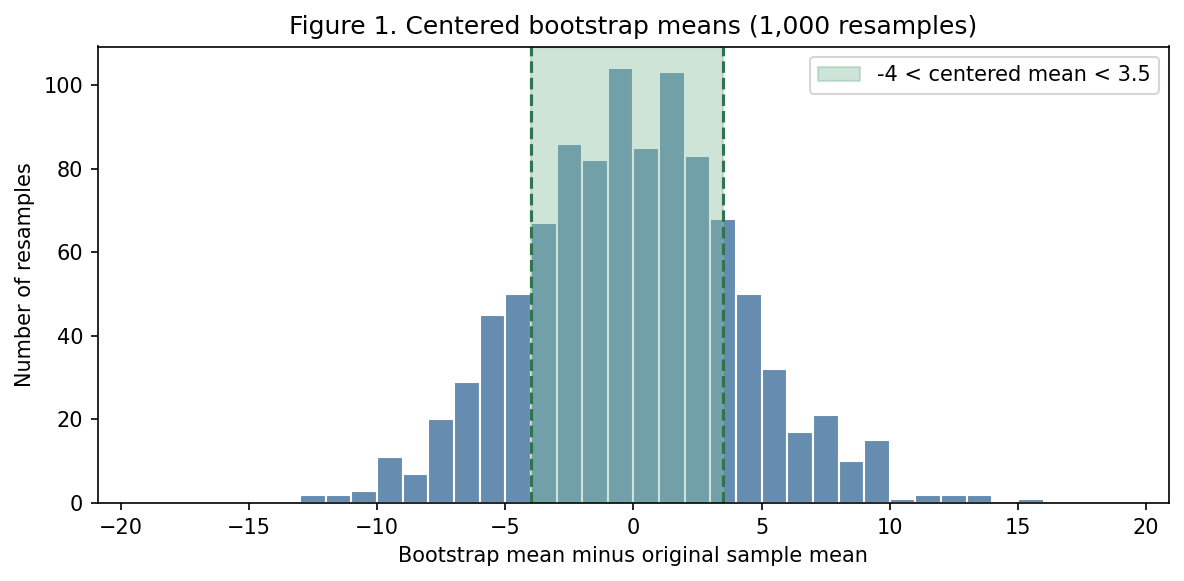

### Task 3

Each entry below summarises 20 complete estimates made with the indicated number of bootstrap samples.

| Number of bootstrap samples, $N_B$ | Mean of 20 estimates | Standard deviation of 20 estimates |
|---:|---:|---:|
| 100 | 0.62750 | 0.04025 |
| 1,000 | 0.62330 | 0.01411 |
| 10,000 | 0.62190 | 0.00481 |

Figure 2 shows the decrease in variation between runs as the number of bootstrap samples increases.

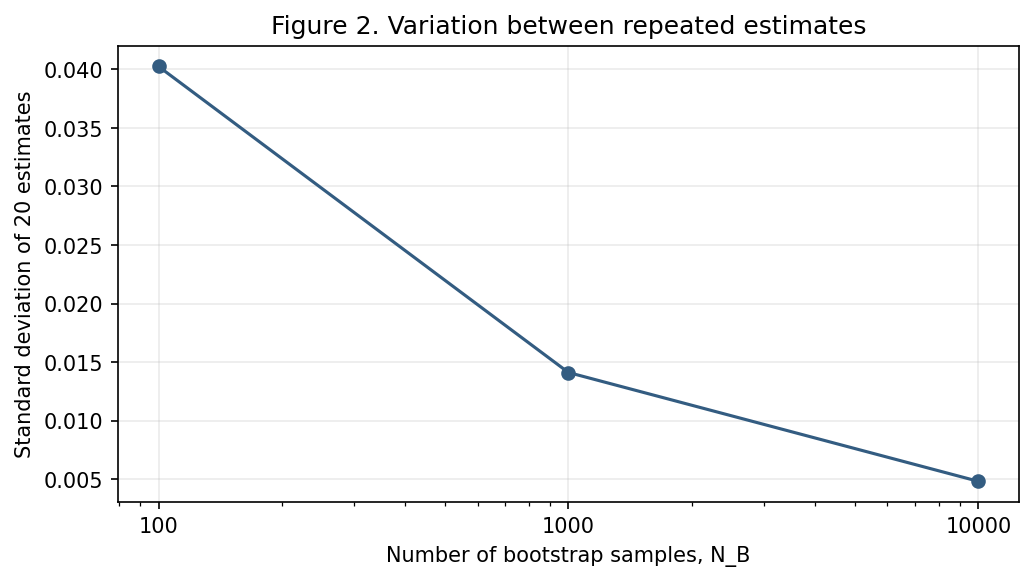

### Task 4

The sample standard deviation was **13.9048**, giving an estimated standard error of **4.3971** for the mean of ten observations. The normal model gave **0.6055**. This is about **0.0355** below the single bootstrap estimate of 0.6410 from Task 2.

## Analysis and discussion

### Task 2

The bootstrap result of 0.6410 means that 64.1% of the 1,000 resampled means differed from the original sample mean by an amount between −4 and 3.5. This is possible even though every original observation is much larger than 3.5: the interval applies to the difference between two means, not to the observations themselves. A new bootstrap run can give a slightly different result because its resamples are random.

### Task 3

The standard deviation of the 20 estimates decreased from **0.04025** with 100 bootstrap samples to **0.01411** with 1,000 and **0.00481** with 10,000. The mean estimates, 0.62750, 0.62330 and 0.62190, were also fairly similar. More resamples therefore made the calculation more stable across repeated runs. An individual run can still be higher or lower by chance; increasing $N_B$ does not guarantee that every estimate moves in one direction.

### Task 4

The normal model estimate of 0.6055 was close to, but lower than, the Task 2 bootstrap estimate of 0.6410. It was also close to the means of the repeated bootstrap estimates in Task 3. The methods need not agree exactly. The normal calculation assumes a distributional shape and estimates its standard deviation from only ten values. The bootstrap uses the observed values as its resampling distribution and also has random variation when a finite number of resamples is used.

The main limitation is the small original sample. Increasing the number of bootstrap samples makes the resampling calculation more stable, but it does not provide more original observations or remove uncertainty about the unknown population.

## Code

### Task 1 - Data and bootstrap function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf, sqrt

# The ten observations and interval limits from the assignment
sample = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69], dtype=float)
a = -4.0
b = 3.5
n = len(sample)
x_bar = float(np.mean(sample))


def bootstrap_estimate(sample, a, b, n_bootstrap, rng):
    """Draw n_bootstrap samples and estimate P(a < sample mean - mu < b)."""
    original_mean = np.mean(sample)  # Our estimate of the unknown mu
    centered_means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        bootstrap_sample = rng.choice(sample, size=len(sample), replace=True)
        centered_means[i] = np.mean(bootstrap_sample) - original_mean

    successes = (a < centered_means) & (centered_means < b)
    return float(np.mean(successes)), int(np.sum(successes)), centered_means


print(f"Sample mean: {x_bar:.2f}")

Sample mean: 76.70


### Task 2 - Estimate and Figure 1

Number inside the interval: 641 of 1000
Bootstrap estimate of p: 0.6410


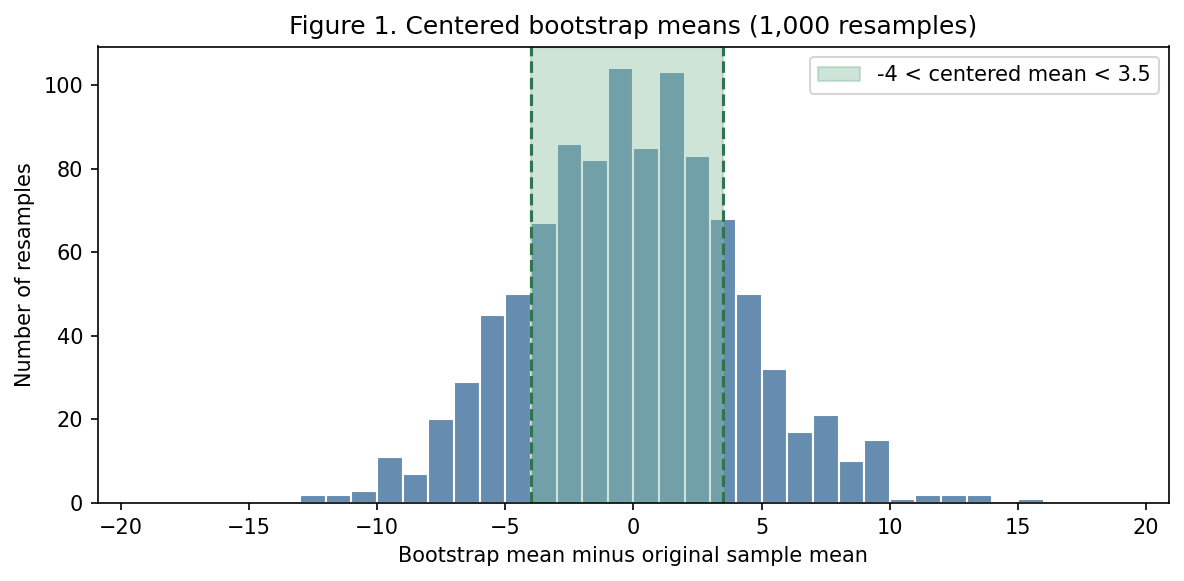

In [ ]:
# One estimate using exactly 1,000 bootstrap samples
rng_task2 = np.random.default_rng(2026)
n_bootstrap_task2 = 1000
p_bootstrap, n_successes, centered_means = bootstrap_estimate(
    sample, a, b, n_bootstrap_task2, rng_task2
)

print(f"Number inside the interval: {n_successes} of {n_bootstrap_task2}")
print(f"Bootstrap estimate of p: {p_bootstrap:.4f}")

# Show the statistic that the assignment asks about
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(centered_means, bins=np.arange(-19, 20, 1), edgecolor="white", color="#668db0")
ax.axvspan(a, b, color="#83bd9c", alpha=0.4, label="-4 < centered mean < 3.5")
ax.axvline(a, color="#30734c", linestyle="--")
ax.axvline(b, color="#30734c", linestyle="--")
ax.set(xlabel="Bootstrap mean minus original sample mean", ylabel="Number of resamples",
       title="Figure 1. Centered bootstrap means (1,000 resamples)")
ax.legend()
fig.tight_layout()

### Task 3 - Repeated estimates and Figure 2

  N_B  Mean of 20 estimates  Standard deviation
  100               0.62750             0.04025
 1000               0.62330             0.01411
10000               0.62190             0.00481


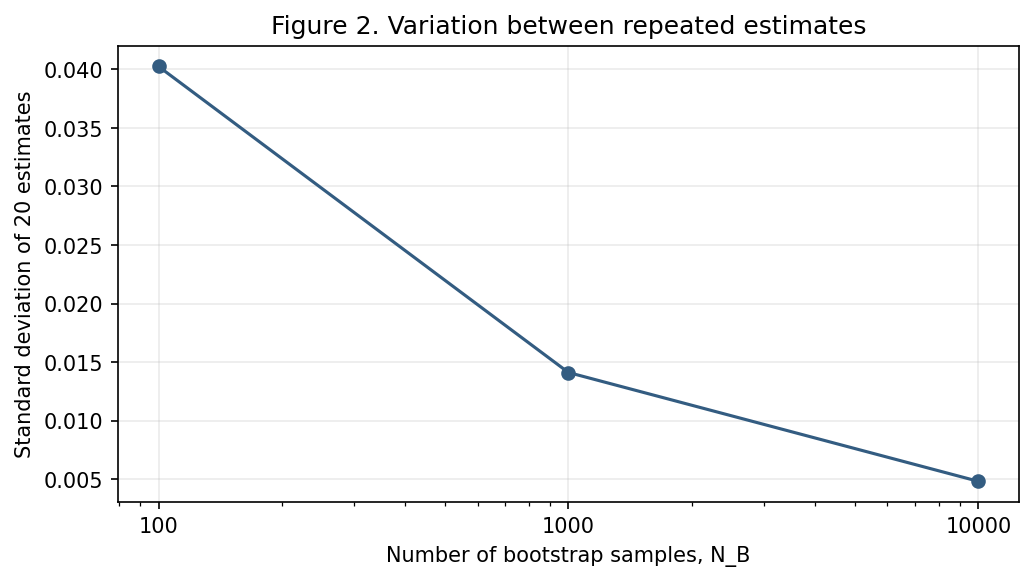

In [ ]:
# Repeat the full estimation 20 times for each value of N_B
rng_task3 = np.random.default_rng(2027)
n_bootstrap_values = [100, 1000, 10000]
repetitions = 20
rows = []

for n_bootstrap in n_bootstrap_values:
    estimates = []
    for _ in range(repetitions):
        estimate, _, _ = bootstrap_estimate(sample, a, b, n_bootstrap, rng_task3)
        estimates.append(estimate)
    rows.append({
        "N_B": n_bootstrap,
        "Mean of 20 estimates": np.mean(estimates),
        "Standard deviation": np.std(estimates, ddof=1),
    })

stability_table = pd.DataFrame(rows)
print(stability_table.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(stability_table["N_B"], stability_table["Standard deviation"], "o-", color="#335c81")
ax.set_xscale("log")
ax.set_xticks(n_bootstrap_values, [str(value) for value in n_bootstrap_values])
ax.set(xlabel="Number of bootstrap samples, N_B", ylabel="Standard deviation of 20 estimates",
       title="Figure 2. Variation between repeated estimates")
ax.grid(alpha=0.25)
fig.tight_layout()

### Task 4 - Normal model comparison

In [ ]:
# Normal model: the sample mean has standard deviation sigma / sqrt(n)
sample_sd = float(np.std(sample, ddof=1))  # Estimate unknown sigma
standard_error = sample_sd / sqrt(n)


def standard_normal_cdf(z):
    return 0.5 * (1 + erf(z / sqrt(2)))


z_a = a / standard_error
z_b = b / standard_error
p_normal = standard_normal_cdf(z_b) - standard_normal_cdf(z_a)

print(f"Sample standard deviation: {sample_sd:.4f}")
print(f"Estimated standard error: {standard_error:.4f}")
print(f"z_a = {z_a:.4f}, z_b = {z_b:.4f}")
print(f"Normal model estimate: {p_normal:.4f}")
print(f"Task 2 bootstrap estimate: {p_bootstrap:.4f}")
print(f"Absolute difference: {abs(p_normal - p_bootstrap):.4f}")

Sample standard deviation: 13.9048
Estimated standard error: 4.3971
z_a = -0.9097, z_b = 0.7960
Normal model estimate: 0.6055
Task 2 bootstrap estimate: 0.6410
Absolute difference: 0.0355
